## Procesamiento de Imágenes con Python

Python permite procesar imágenes para aplicaciones reales como autos autónomos o sistemas de seguridad. En este ejemplo interactivo, usaremos código para analizar una fotografía en tres pasos:

**1. Cargar imagen desde Internet:**
Python leerá una imagen usando un enlace (URL) y la guardará en la memoria como una matriz de números. Cada número representa un color.

**2. Convertir a escala de grises:**
Transformamos la imagen original a blanco y negro. Esto hace que el proceso sea más rápido y eficiente, ya que el programa solo evalúa el nivel de brillo de cada punto.

**3. Detectar bordes (Filtro Canny):**
Usamos el algoritmo "Canny" para encontrar cambios bruscos de luz o contraste. Si un punto oscuro está junto a uno claro, el programa detecta una frontera. El resultado es un mapa con los bordes principales de la imagen.

---
**Instrucción:** Haz clic en "Play" en la celda de código inferior para ejecutar la transformación.

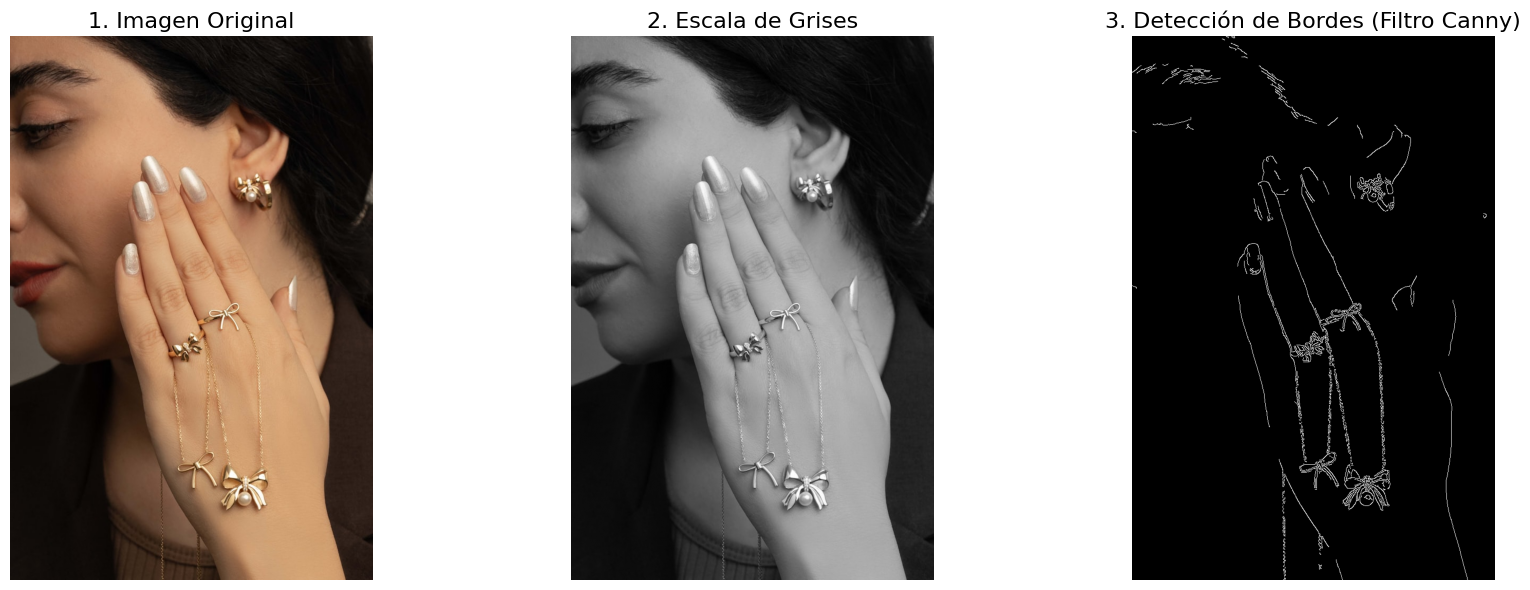

In [3]:
# Importamos las librerías necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# 1. Descargar una imagen directamente desde una URL
url = "https://images.unsplash.com/photo-1770721478216-3e5dbbe8dcc2?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, -1)

# OpenCV lee las imágenes en formato BGR (Azul, Verde, Rojo),
# pero matplotlib las muestra en RGB. Hacemos la conversión:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Procesamiento de la imagen
# A. Convertir a escala de grises
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# B. Aplicar el algoritmo Canny para detectar bordes
# Los valores 100 y 200 son los umbrales de intensidad para decidir qué es un borde
bordes = cv2.Canny(img_gray, 100, 200)

# 3. Visualización de los resultados
# Creamos una figura con 3 subgráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Imagen Original
axes[0].imshow(img_rgb)
axes[0].set_title('1. Imagen Original', fontsize=16)
axes[0].axis('off') # Ocultar los ejes (números)

# Escala de Grises
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('2. Escala de Grises', fontsize=16)
axes[1].axis('off')

# Detección de Bordes
axes[2].imshow(bordes, cmap='gray')
axes[2].set_title('3. Detección de Bordes (Filtro Canny)', fontsize=16)
axes[2].axis('off')

# Mostrar el resultado final
plt.tight_layout()
plt.show()

## Análisis de Movimiento: Posición, Velocidad y Aceleración

En la física y la ingeniería, el movimiento de una partícula se analiza estudiando su posición, velocidad y aceleración. La velocidad es la derivada (o cambio) de la posición, y la aceleración es la derivada de la velocidad.

En este ejemplo, simularemos el movimiento de una partícula que oscila y se detiene lentamente (como un resorte con fricción). Haremos lo siguiente:

**1. Definir la posición:**
Crearemos una secuencia de tiempo y calcularemos la posición de la partícula en cada instante usando una función matemática.

**2. Calcular diferenciales (Derivadas numéricas):**
En lugar de resolver las ecuaciones a mano, le pediremos a Python que calcule la velocidad y la aceleración midiendo la diferencia de posición entre cada instante de tiempo.

**3. Graficar los resultados:**
Generaremos tres gráficos apilados para comparar visualmente cómo interactúan la posición, la velocidad y la aceleración en el mismo periodo de tiempo.

---
**Instrucción:** Haz clic en "Play" en la celda inferior para calcular las derivadas y visualizar los tres gráficos del movimiento.

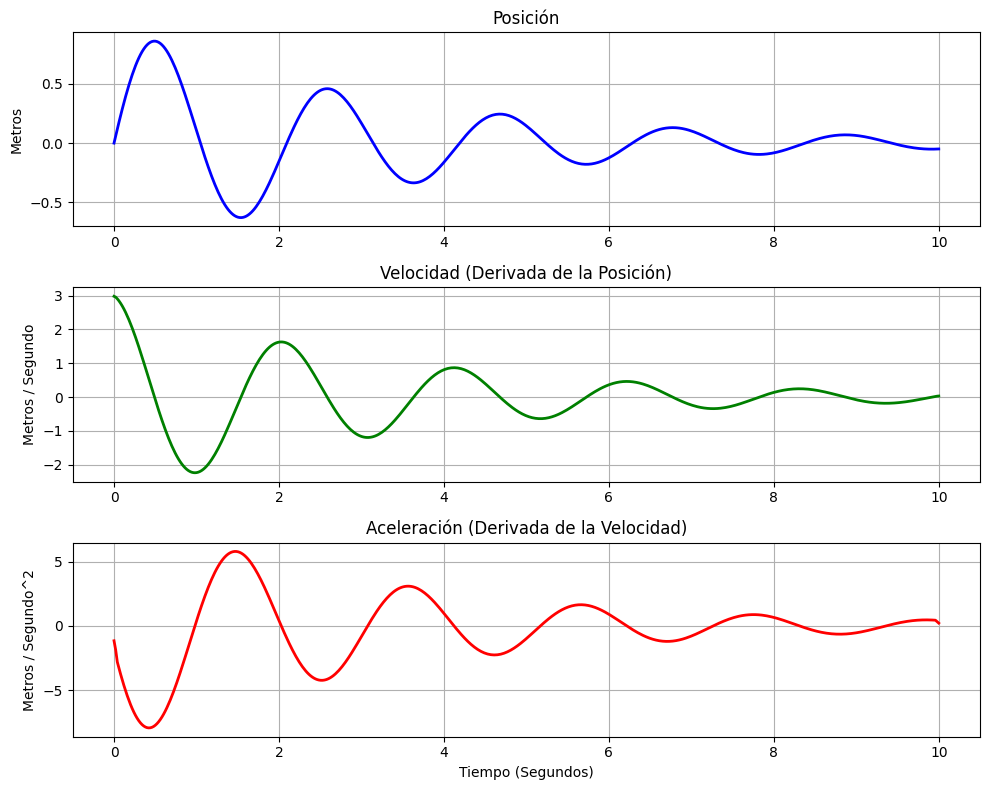

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el tiempo y la posición
# Creamos 500 puntos de tiempo entre 0 y 10 segundos
t = np.linspace(0, 10, 500)

# Ecuación de la posición: Oscilación que disminuye con el tiempo
posicion = np.sin(3 * t) * np.exp(-0.3 * t)

# 2. Calcular diferenciales (Derivadas numéricas)
# La velocidad es el cambio de posición en el tiempo (dx/dt)
velocidad = np.gradient(posicion, t)

# La aceleración es el cambio de velocidad en el tiempo (dv/dt)
aceleracion = np.gradient(velocidad, t)

# 3. Graficar los resultados
# Creamos una figura con 3 gráficos apilados (3 filas, 1 columna)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))

# Gráfico de Posición
ax1.plot(t, posicion, color='blue', linewidth=2)
ax1.set_title('Posición')
ax1.set_ylabel('Metros')
ax1.grid(True)

# Gráfico de Velocidad
ax2.plot(t, velocidad, color='green', linewidth=2)
ax2.set_title('Velocidad (Derivada de la Posición)')
ax2.set_ylabel('Metros / Segundo')
ax2.grid(True)

# Gráfico de Aceleración
ax3.plot(t, aceleracion, color='red', linewidth=2)
ax3.set_title('Aceleración (Derivada de la Velocidad)')
ax3.set_xlabel('Tiempo (Segundos)')
ax3.set_ylabel('Metros / Segundo^2')
ax3.grid(True)

# Ajustar los espacios para que los textos no se superpongan
plt.tight_layout()

# Mostrar el resultado final
plt.show()

## Análisis de Datos por Capas: Efecto del Mundial en la Natalidad

Para crear gráficos complejos en análisis de datos, se suele usar una herramienta llamada "ggplot". Esta herramienta nació en otro lenguaje, pero en Python la usamos a través de una librería llamada "plotnine".

El sistema ggplot funciona dibujando por capas. Primero pones el lienzo, luego los datos, luego las líneas, y finalmente los adornos.

En este ejemplo, vamos a graficar una estimación simulada de los nacimientos en Argentina antes y después del Mundial de Qatar 2022. Buscaremos visualmente si hubo un aumento de nacimientos exactamente 9 meses después de la final.

Haremos lo siguiente:

**1. Generar los datos:**
Crearemos una tabla con fechas desde 2021 hasta 2024. Simularemos una tendencia general de nacimientos y agregaremos un pico artificial 9 meses después de diciembre de 2022 para ilustrar el concepto.

**2. Construir el gráfico por capas:**
* Capa base: Los ejes de tiempo y cantidad.
* Capa de datos: La línea principal que conecta los nacimientos mes a mes.
* Capa de tendencia: Una curva suavizada matemática que ignora el ruido y muestra la dirección general.
* Capa de eventos: Líneas verticales marcando el mes de la final del Mundial y el periodo de 9 meses después.

---
**Instrucción:** Ejecuta la celda inferior para instalar la herramienta necesaria, generar los datos y procesar el gráfico.

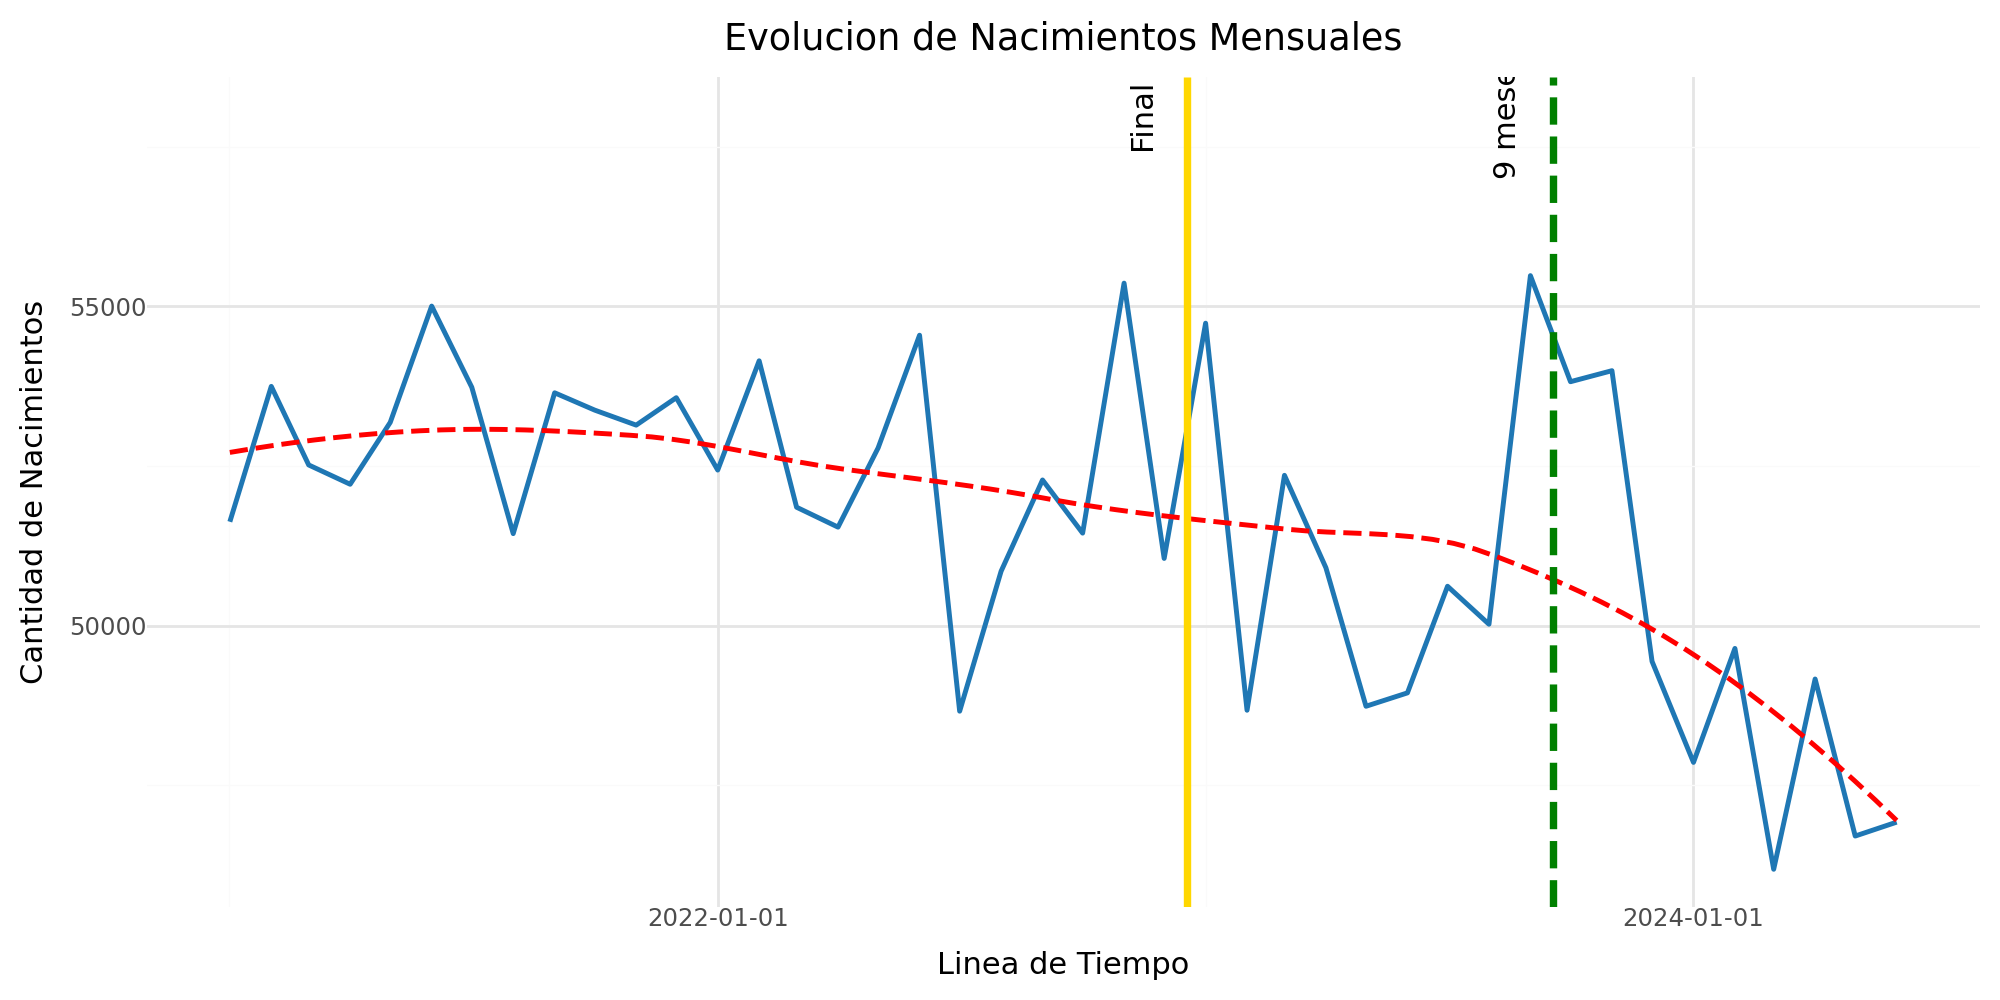

In [13]:
# Instalar las librerias necesarias, incluyendo scikit-misc para la linea suavizada
!pip install plotnine pandas numpy scikit-misc

import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_line, geom_smooth, geom_vline, annotate, labs, theme_minimal, theme

# Ignorar advertencias de la consola para mantenerla limpia
import warnings
warnings.filterwarnings('ignore')

# 1. Crear datos simulados
meses = pd.date_range(start='2021-01-01', end='2024-06-01', freq='MS')
cantidad_meses = len(meses)

# Crear la tendencia y el ruido
base_nacimientos = np.linspace(55000, 48000, cantidad_meses)
ruido = np.random.normal(0, 1500, cantidad_meses)

# Armamos la tabla de datos principal
df = pd.DataFrame({
    'Fecha': meses,
    'Nacimientos': base_nacimientos + ruido
})

# Aplicamos el pico de nacimientos
pico_condicion = (df['Fecha'] >= '2023-09-01') & (df['Fecha'] <= '2023-11-30')
df.loc[pico_condicion, 'Nacimientos'] += 6000

# Convertir las fechas para el grafico
fecha_mundial = pd.to_datetime('2022-12-18')
fecha_texto_mundial = pd.to_datetime('2022-11-15')
fecha_pico = pd.to_datetime('2023-09-18')
fecha_texto_pico = pd.to_datetime('2023-08-15')

# 2. Construir el grafico complejo por capas
grafico = (
    ggplot(df, aes(x='Fecha', y='Nacimientos'))
    + geom_line(color='#1f77b4', size=1)
    + geom_smooth(method='loess', color='red', linetype='dashed', se=False)
    + geom_vline(xintercept=fecha_mundial, color='gold', size=1.5)
    + annotate('text', x=fecha_texto_mundial, y=58000, label='Final', angle=90)
    + geom_vline(xintercept=fecha_pico, color='green', size=1.5, linetype='dashed')
    + annotate('text', x=fecha_texto_pico, y=58000, label='9 meses', angle=90)
    + labs(
        title='Evolucion de Nacimientos Mensuales',
        x='Linea de Tiempo',
        y='Cantidad de Nacimientos'
    )
    + theme_minimal()
    + theme(figure_size=(10, 5))
)

# Mostrar el grafico llamando directamente a la variable
grafico

## Logística Militar: Optimización de Rutas de Suministro

En escenarios complejos como una guerra, la teoría de grafos se utiliza para planificar estrategias. Los puntos del mapa representan bases, puestos de avanzada o trincheras, y las líneas representan las rutas terrestres disponibles. El valor en cada ruta indica el tiempo o el nivel de peligro para cruzarla.

En este ejercicio, simularemos un mapa táctico con múltiples ubicaciones. Nuestro objetivo es enviar suministros desde el Cuartel General hasta el Frente de Batalla en el menor tiempo posible, evitando rutas lentas o bloqueadas.

Haremos lo siguiente:

**1. Construir el mapa táctico:**
Crearemos una red amplia con más de una docena de puntos estratégicos (Aeródromo, Ruinas, Colina 7, Trincheras, etc.) y múltiples rutas posibles con distintos tiempos de viaje en horas.

**2. Calcular la ruta táctica:**
Le pediremos al algoritmo de Dijkstra que evalúe todas las combinaciones posibles en el mapa para encontrar el camino que tome la menor cantidad de horas hasta el frente de batalla.

**3. Visualizar el plan de acción:**
Dibujaremos el mapa completo con colores oscuros estilo militar. Las rutas normales se verán en gris claro, y la ruta de suministro principal que debemos tomar estará marcada en rojo grueso.

---
**Instrucción:** Ejecuta la celda inferior para procesar la red militar y visualizar el mapa de la misión.

Ruta tactica recomendada: ['Cuartel General', 'Base Suministros', 'Cruce Rio', 'Ruinas', 'Colina 7', 'Trincheras', 'Frente de Batalla']
Tiempo total estimado: 18 horas


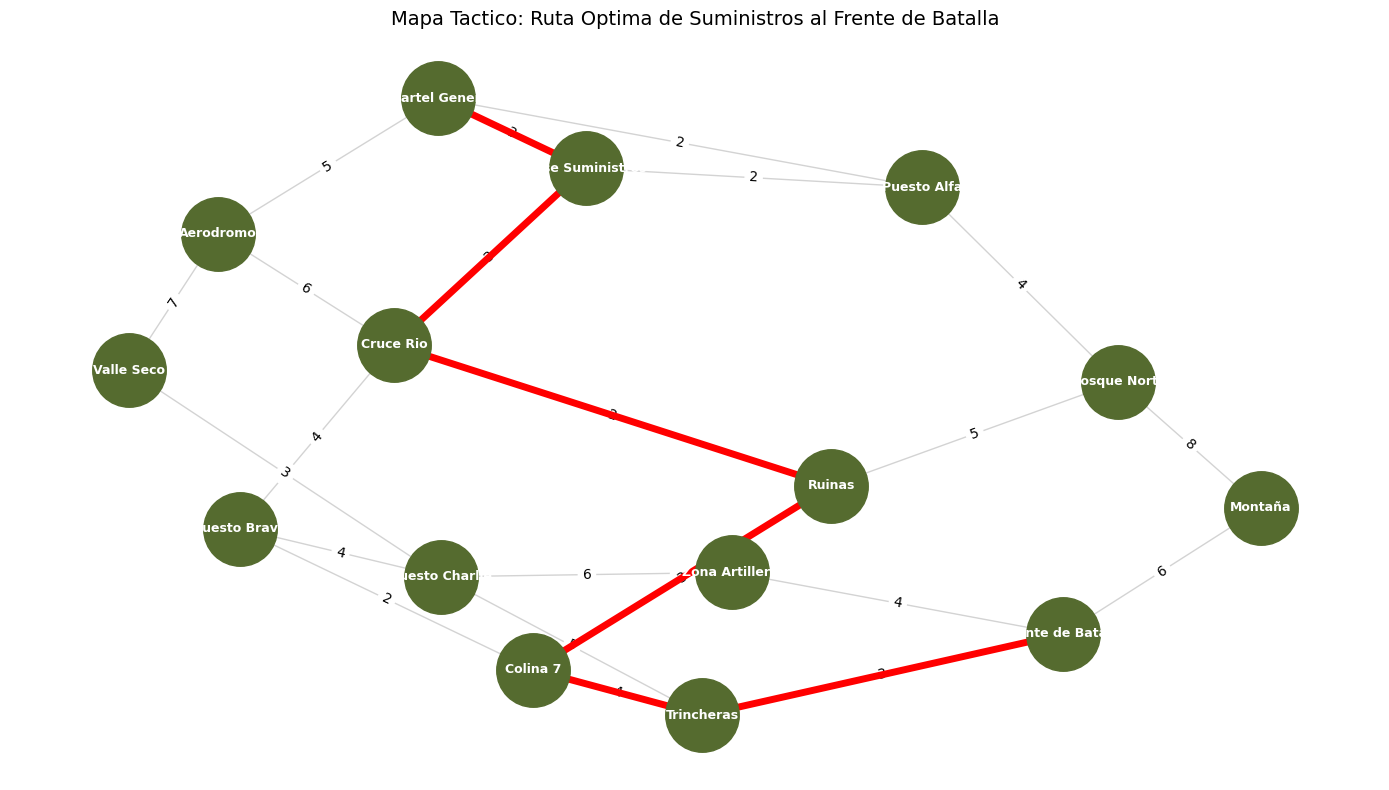

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Crear el mapa estrategico (Grafo)
G = nx.Graph()

# Agregar multiples conexiones simulando rutas militares
# Formato: (Punto_Origen, Punto_Destino, Tiempo_Horas)
conexiones = [
    ('Cuartel General', 'Puesto Alfa', 2),
    ('Cuartel General', 'Base Suministros', 3),
    ('Cuartel General', 'Aerodromo', 5),
    ('Puesto Alfa', 'Bosque Norte', 4),
    ('Puesto Alfa', 'Base Suministros', 2),
    ('Base Suministros', 'Cruce Rio', 3),
    ('Aerodromo', 'Cruce Rio', 6),
    ('Bosque Norte', 'Ruinas', 5),
    ('Cruce Rio', 'Ruinas', 2),
    ('Cruce Rio', 'Puesto Bravo', 4),
    ('Aerodromo', 'Valle Seco', 7),
    ('Ruinas', 'Colina 7', 3),
    ('Puesto Bravo', 'Colina 7', 2),
    ('Puesto Bravo', 'Puesto Charlie', 4),
    ('Valle Seco', 'Puesto Charlie', 3),
    ('Colina 7', 'Trincheras', 4),
    ('Puesto Charlie', 'Trincheras', 5),
    ('Puesto Charlie', 'Zona Artilleria', 6),
    ('Trincheras', 'Frente de Batalla', 3),
    ('Zona Artilleria', 'Frente de Batalla', 4),
    ('Bosque Norte', 'Montaña', 8),
    ('Montaña', 'Frente de Batalla', 6)
]

G.add_weighted_edges_from(conexiones)

# 2. Calcular la ruta mas rapida (Dijkstra)
# Buscamos la ruta desde el Cuartel General hasta el Frente de Batalla
ruta_optima = nx.shortest_path(G, source='Cuartel General', target='Frente de Batalla', weight='weight')
tiempo_total = nx.shortest_path_length(G, source='Cuartel General', target='Frente de Batalla', weight='weight')

print(f"Ruta tactica recomendada: {ruta_optima}")
print(f"Tiempo total estimado: {tiempo_total} horas")

# 3. Dibujar el mapa estrategico
fig, ax = plt.subplots(figsize=(14, 8))

# Usar un algoritmo de distribucion (spring_layout) dando mas espacio entre los puntos (k)
posiciones = nx.spring_layout(G, k=0.9, seed=42)

# Dibujar los nodos con estilo militar
nx.draw(G, posiciones, ax=ax, with_labels=True, node_color='darkolivegreen',
        font_color='white', node_size=2800, font_size=9, font_weight='bold', edge_color='lightgray')

# Dibujar los valores de tiempo en las rutas
pesos = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, posiciones, edge_labels=pesos, font_size=10, ax=ax)

# Resaltar la ruta de suministro optima en color rojo y mas gruesa
conexiones_optimas = [(ruta_optima[i], ruta_optima[i+1]) for i in range(len(ruta_optima)-1)]
nx.draw_networkx_edges(G, posiciones, edgelist=conexiones_optimas, edge_color='red', width=5, ax=ax)

# Dar formato final al grafico
ax.set_title('Mapa Tactico: Ruta Optima de Suministros al Frente de Batalla', fontsize=14)
ax.axis('off')

# Mostrar el grafico final en pantalla
plt.tight_layout()
plt.show()

## Inteligencia Artificial: Predicción de Datos

El aprendizaje automático (Machine Learning) permite que una computadora encuentre patrones en los datos para hacer predicciones.

En este ejemplo, crearemos un modelo de Inteligencia Artificial muy básico. Le entregaremos datos simulados sobre el tamaño de distintas casas y sus precios de venta. La computadora analizará estos puntos y trazará una "línea de predicción" matemática. Con esta línea, el programa podrá adivinar el precio de cualquier casa nueva basándose solo en su tamaño.

**Instrucción:** Ejecuta la celda para entrenar el modelo y ver el gráfico de predicción.

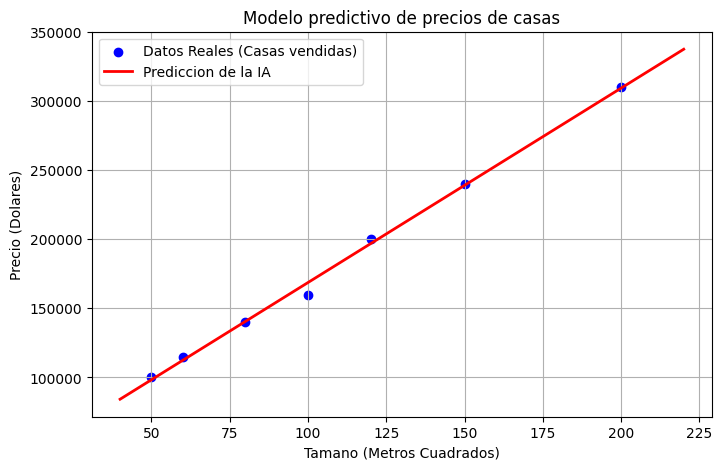

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Crear datos de entrenamiento (Tamaño en metros cuadrados vs Precio)
tamanos = np.array([50, 60, 80, 100, 120, 150, 200]).reshape(-1, 1)
precios = np.array([100000, 115000, 140000, 160000, 200000, 240000, 310000])

# 2. Entrenar el modelo de Inteligencia Artificial
modelo = LinearRegression()
modelo.fit(tamanos, precios)

# 3. Hacer predicciones para una linea continua
tamanos_prueba = np.linspace(40, 220, 100).reshape(-1, 1)
precios_predichos = modelo.predict(tamanos_prueba)

# 4. Graficar los datos reales y la prediccion de la IA
plt.figure(figsize=(8, 5))
plt.scatter(tamanos, precios, color='blue', label='Datos Reales (Casas vendidas)')
plt.plot(tamanos_prueba, precios_predichos, color='red', linewidth=2, label='Prediccion de la IA')

plt.title('Modelo predictivo de precios de casas')
plt.xlabel('Tamano (Metros Cuadrados)')
plt.ylabel('Precio (Dolares)')
plt.legend()
plt.grid(True)
plt.show()

## Extracción de Datos en la Web (Web Scraping)

Python puede conectarse a internet, leer páginas web completas y procesar su contenido en fracciones de segundo.

En este código, le pediremos al programa que visite el artículo de Wikipedia sobre el lenguaje de programación Python. El código leerá todo el texto visible, separará las palabras y contará cuáles son las más utilizadas, ignorando conectores o palabras cortas. Finalmente, mostrará un gráfico con el resultado.

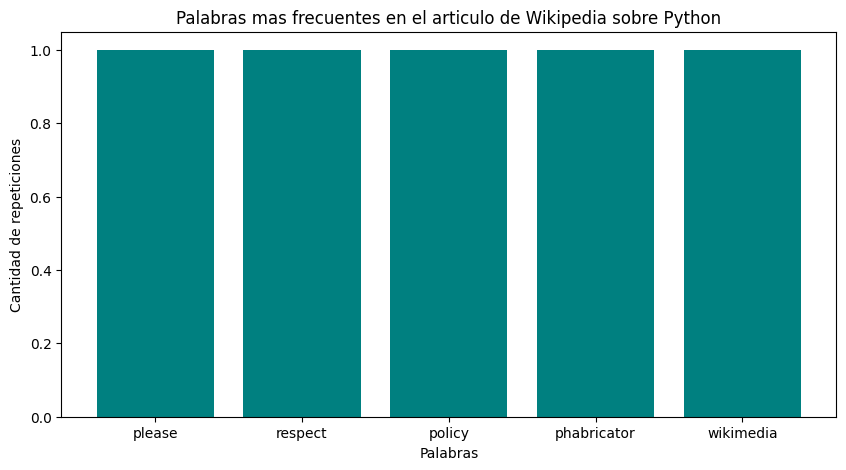

In [19]:
import requests
from bs4 import BeautifulSoup
from collections import Counter
import matplotlib.pyplot as plt
import re

# 1. Descargar el contenido de la pagina web
url = 'https://es.wikipedia.org/wiki/Python'
respuesta = requests.get(url)

# 2. Extraer el texto usando BeautifulSoup
sopa = BeautifulSoup(respuesta.text, 'html.parser')
texto_puro = sopa.get_text()

# 3. Limpiar el texto y contar las palabras
# Convertir a minusculas y extraer solo palabras largas (mas de 5 letras)
palabras = re.findall(r'\b[a-záéíóúñA-ZÁÉÍÓÚÑ]{6,}\b', texto_puro.lower())

# Contar las palabras usando la herramienta Counter
conteo = Counter(palabras)
palabras_comunes = conteo.most_common(10) # Tomar las 10 mas repetidas

# Separar las palabras y sus frecuencias para el grafico
etiquetas = [par[0] for par in palabras_comunes]
valores = [par[1] for par in palabras_comunes]

# 4. Graficar los resultados
plt.figure(figsize=(10, 5))
plt.bar(etiquetas, valores, color='teal')
plt.title('Palabras mas frecuentes en el articulo de Wikipedia sobre Python')
plt.xlabel('Palabras')
plt.ylabel('Cantidad de repeticiones')
plt.show()

## Matemáticas Visuales: Fractales

Un fractal es una figura matemática infinita. Por más que te acerques, seguirás viendo patrones complejos que se repiten. Se calculan evaluando millones de puntos matemáticos.

Aquí generaremos el famoso "Conjunto de Mandelbrot". El código revisa una cuadrícula de números complejos y aplica una fórmula recursiva: $z = z^2 + c$. Dependiendo de qué tan rápido el resultado se dispara hacia el infinito, asignamos un color a ese punto.

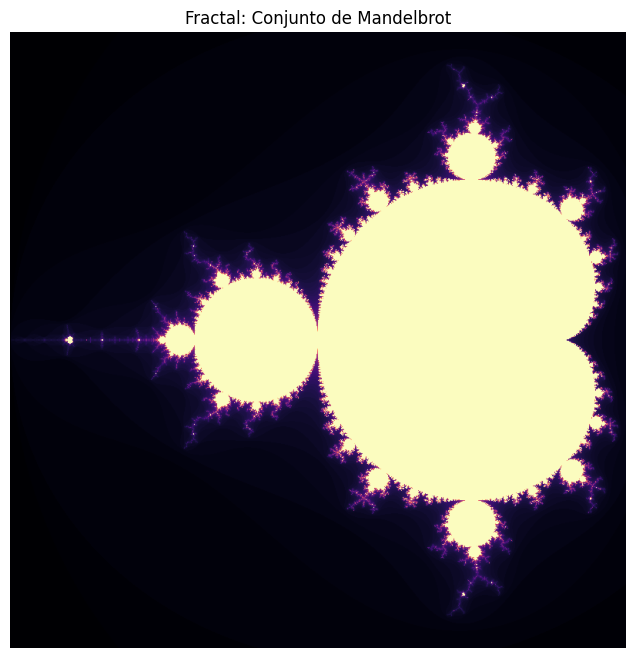

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir la resolucion de la imagen y los limites matematicos
ancho, alto = 800, 800
x_min, x_max = -2.0, 0.5
y_min, y_max = -1.25, 1.25
iteraciones_maximas = 100

# 2. Crear una matriz de numeros complejos
x = np.linspace(x_min, x_max, ancho)
y = np.linspace(y_min, y_max, alto)
X, Y = np.meshgrid(x, y)
C = X + 1j * Y # Matriz de numeros complejos

# 3. Calcular el fractal
Z = np.zeros_like(C)
imagen = np.zeros(C.shape, dtype=float)

for i in range(iteraciones_maximas):
    # La formula del fractal de Mandelbrot
    mascara = np.abs(Z) <= 2
    Z[mascara] = Z[mascara]**2 + C[mascara]
    imagen[mascara] = i

# 4. Dibujar el fractal
plt.figure(figsize=(8, 8))
plt.imshow(imagen, cmap='magma', extent=[x_min, x_max, y_min, y_max])
plt.title('Fractal: Conjunto de Mandelbrot')
plt.axis('off')
plt.show()

## Criptografía: Cifrado de Mensajes Secretos

En el mundo digital, las contraseñas y mensajes de chat viajan a través de internet usando algoritmos matemáticos que desordenan el texto, haciéndolo ilegible para cualquiera que no tenga la clave.

En este ejemplo, usaremos una librería de encriptación profesional para generar una clave única, encriptar un texto normal en un código ilegible y luego desencriptarlo de vuelta.

In [21]:
# Instalar la libreria de criptografia si es necesario
!pip install cryptography

from cryptography.fernet import Fernet

# 1. Generar una clave secreta matematica (Solo el emisor y receptor la deben tener)
clave_secreta = Fernet.generate_key()
sistema_cifrado = Fernet(clave_secreta)

print(f"Clave matematica generada:\n{clave_secreta.decode()}\n")

# 2. El mensaje original
mensaje_original = "El objetivo principal del curso es desarrollar el pensamiento algoritmico."
print(f"1. Mensaje Original: \n{mensaje_original}\n")

# 3. Encriptar el mensaje
mensaje_encriptado = sistema_cifrado.encrypt(mensaje_original.encode())
print(f"2. Mensaje Encriptado (Lo que viaja por internet): \n{mensaje_encriptado.decode()}\n")

# 4. Desencriptar el mensaje usando la misma clave
mensaje_desencriptado = sistema_cifrado.decrypt(mensaje_encriptado).decode()
print(f"3. Mensaje Desencriptado (Lo que lee el receptor): \n{mensaje_desencriptado}")

Clave matematica generada:
7INV5ySBEJNFGiE4RRoU82pq6__K6BXwLSJT4Y0zmko=

1. Mensaje Original: 
El objetivo principal del curso es desarrollar el pensamiento algoritmico.

2. Mensaje Encriptado (Lo que viaja por internet): 
gAAAAABpocQzNDMg575LXF_iOaxPfR1gGkBIjVu-oV_vJVUHZ50xQGK43hm5ZjjrHWYfDkOBpXnVLWKu6Oi9_KKPnApRJXcFoHKcVEW63vzQpVA1OwsfLu4VG-z08ZoVZquVL2AWsZm_1i1nETxWQsGIlQmVZJZzip8wllhiNvKjkAGEa0Jdukk=

3. Mensaje Desencriptado (Lo que lee el receptor): 
El objetivo principal del curso es desarrollar el pensamiento algoritmico.


## Calculando Pi por Simulación Física (Método Monte Carlo)

Existen muchas formas de calcular el valor de Pi ($\pi$). Una de las más visuales es el "Método de Monte Carlo". Imagina que lanzas miles de dardos al azar sobre un tablero cuadrado que tiene un círculo dibujado adentro.

Comparando matemáticamente la cantidad de dardos que cayeron dentro del círculo versus el total de dardos lanzados, podemos aproximar el valor exacto de la constante. La ecuación es: $\pi \approx 4 \times (\text{Puntos dentro} / \text{Total de puntos})$.

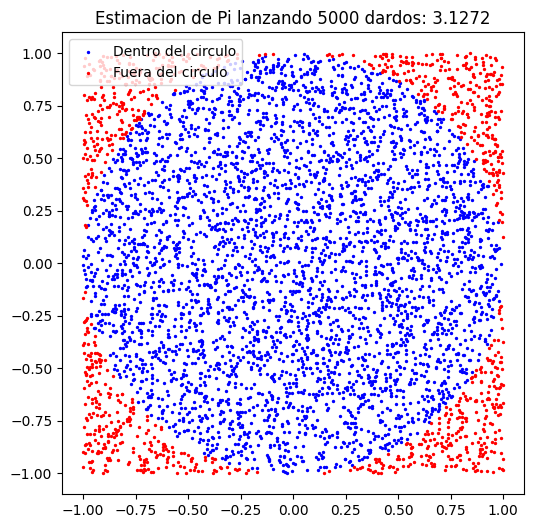

In [22]:
import numpy as np
import matplotlib.pyplot as plt

puntos_totales = 5000

# 1. Generar coordenadas X e Y al azar entre -1 y 1
x = np.random.uniform(-1, 1, puntos_totales)
y = np.random.uniform(-1, 1, puntos_totales)

# 2. Calcular la distancia al centro usando el Teorema de Pitagoras
distancia = x**2 + y**2

# 3. Revisar cuales puntos estan dentro del circulo (distancia <= 1)
dentro = distancia <= 1
fuera = distancia > 1

# Calcular Pi
puntos_dentro = np.sum(dentro)
pi_estimado = 4 * (puntos_dentro / puntos_totales)

# 4. Graficar la simulacion
plt.figure(figsize=(6, 6))
plt.scatter(x[dentro], y[dentro], color='blue', s=2, label='Dentro del circulo')
plt.scatter(x[fuera], y[fuera], color='red', s=2, label='Fuera del circulo')

plt.title(f'Estimacion de Pi lanzando {puntos_totales} dardos: {pi_estimado}')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

## La Constante de Euler ($e$) y la sumatoria infinita

El número de Euler ($e \approx 2.71828$) es la base del cálculo y del crecimiento exponencial. Una forma de calcularlo es sumar una serie infinita de fracciones usando factoriales (multiplicaciones consecutivas):

$$e = \sum_{n=0}^{\infty} \frac{1}{n!} = \frac{1}{1} + \frac{1}{1} + \frac{1}{2} + \frac{1}{6} + \frac{1}{24} + \dots$$

Vamos a pedirle a Python que realice estas sumas paso a paso y graficaremos cómo la curva se estabiliza rápidamente hasta llegar al valor exacto.

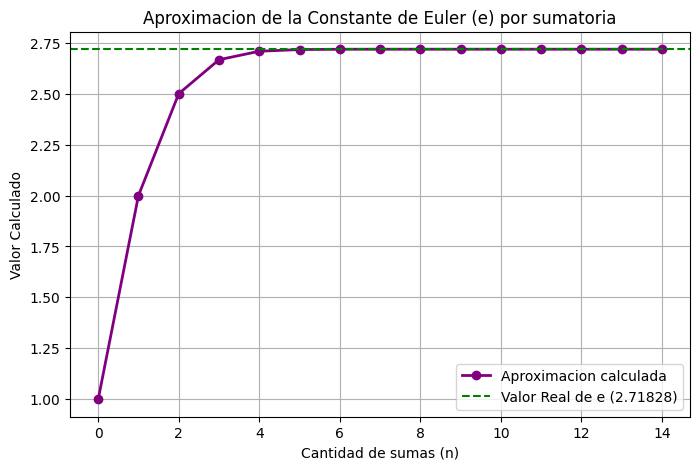

In [23]:
import math
import matplotlib.pyplot as plt

pasos = 15
sumas = []
valor_actual = 0

# 1. Calcular la sumatoria paso a paso
for n in range(pasos):
    valor_actual += 1 / math.factorial(n)
    sumas.append(valor_actual)

# 2. Graficar la convergencia
plt.figure(figsize=(8, 5))
plt.plot(range(pasos), sumas, marker='o', color='purple', linewidth=2, label='Aproximacion calculada')

# Dibujar una linea horizontal mostrando el valor real matematico
plt.axhline(y=math.e, color='green', linestyle='--', label=f'Valor Real de e ({math.e:.5f})')

plt.title('Aproximacion de la Constante de Euler (e) por sumatoria')
plt.xlabel('Cantidad de sumas (n)')
plt.ylabel('Valor Calculado')
plt.legend()
plt.grid(True)
plt.show()

## Cuando el cerebro humano no alcanza: Programación y Matemáticas Superiores

En el nivel universitario, el cálculo simbólico y la capacidad de procesamiento masivo reemplazan al papel y al lápiz. Existen problemas matemáticos que tomarían siglos resolver a mano.

**1. Demostraciones Matemáticas por Computadora:**
En matemáticas puras, la computadora ha logrado resolver conjeturas históricas.
* **El Teorema de los Cuatro Colores:** Propone que cualquier mapa geográfico puede pintarse con solo 4 colores sin que dos regiones vecinas compartan el mismo color. Fue el primer gran teorema matemático probado por una computadora, evaluando sistemáticamente casi 2000 configuraciones complejas posibles, un trabajo inabarcable para una mente humana.
* **La Conjetura de Kepler:** Explica la manera más eficiente de apilar esferas (como naranjas en un supermercado). Fue demostrada usando miles de horas de procesamiento computacional para resolver ecuaciones de optimización tridimensionales.

**2. Cálculo Simbólico de Alta Complejidad:**
Los ingenieros no siempre calculan con números, muchas veces calculan con "letras" (Cálculo Algebraico). Python tiene herramientas como `SymPy` que resuelven derivadas, límites de infinito e integrales masivas de forma analítica exacta.

In [24]:
import sympy as sp

# Le decimos a Python que 'x' no es un numero, sino una variable matematica abstracta
x = sp.Symbol('x')

# Definimos una ecuacion de alta complejidad (Integral de una exponencial cuadratica)
ecuacion = sp.exp(-x**2)

print("Ecuacion original:")
sp.pprint(ecuacion)
print("\n")

# Pedimos a la computadora que calcule la integral desde el infinito negativo al infinito positivo
resultado = sp.integrate(ecuacion, (x, -sp.oo, sp.oo))

print("Resultado analitico de la Integral (Calculo exacto):")
sp.pprint(resultado)

Ecuacion original:
   2
 -x 
ℯ   


Resultado analitico de la Integral (Calculo exacto):
√π


## Ciberseguridad: Rompiendo una contraseña simulada

Los sistemas seguros no guardan tu contraseña en texto normal. La transforman usando una función matemática llamada "Hash", que convierte cualquier palabra en una cadena de caracteres irreconocible. [Image of cryptographic hash function concept]

En este ejercicio, simularemos que un atacante obtuvo la base de datos de una página web con un hash protegido. Usaremos ingeniería social: el atacante sabe que la víctima está organizando una estudiatón y estudia en la universidad, por lo que creó una lista de palabras probables.

El programa aplicará la misma función matemática a cada palabra de la lista. Si el resultado coincide con el hash robado, significa que encontró la contraseña original.

**Instrucción:** Ejecuta la celda para ver cómo la computadora prueba múltiples combinaciones en milisegundos hasta encontrar la clave correcta.

In [25]:
import hashlib
import time

# 1. El hash robado de la base de datos (representa la contraseña secreta)
# Este es el hash SHA-256 de una palabra especifica
hash_objetivo = '87a41da5a1bbddbbec8c823bf1bfdb8f804cc8ffea95b871ed8ec1cdff7bba53'

# 2. Lista de posibles contraseñas basada en ingenieria social
# El atacante usa palabras relacionadas al contexto de la victima
diccionario_pruebas = [
    "admin123",
    "password",
    "universidad",
    "uai2026",
    "estudiaton",
    "programacion100",
    "python2026"
]

print("Iniciando simulacion de ataque de diccionario...\n")
tiempo_inicio = time.time()

# 3. Ciclo de fuerza bruta
clave_encontrada = False

for intento in diccionario_pruebas:
    # Convertir la palabra del diccionario a su formato Hash
    intento_hash = hashlib.sha256(intento.encode()).hexdigest()

    print(f"Probando: {intento} -> Hash: {intento_hash[:15]}...")

    # Comparar el resultado con el hash robado
    if intento_hash == hash_objetivo:
        print(f"\n¡Exito! La contraseña original es: {intento}")
        clave_encontrada = True
        break

if not clave_encontrada:
    print("\nFallo. La contraseña no esta en la lista de pruebas.")

tiempo_fin = time.time()
print(f"Tiempo de procesamiento: {tiempo_fin - tiempo_inicio:.5f} segundos")

Iniciando simulacion de ataque de diccionario...

Probando: admin123 -> Hash: 240be518fabd272...
Probando: password -> Hash: 5e884898da28047...
Probando: universidad -> Hash: 0c8315151c580e3...
Probando: uai2026 -> Hash: 65b015fa43a5913...
Probando: estudiaton -> Hash: 07f3e4eacaf607e...
Probando: programacion100 -> Hash: c7057dc701c19ce...
Probando: python2026 -> Hash: 9881e9b71a00127...

Fallo. La contraseña no esta en la lista de pruebas.
Tiempo de procesamiento: 0.00026 segundos


## Análisis de la aleatoriedad en los decimales de Pi

El número Pi es infinito y sus decimales no siguen ningún patrón lógico. Se considera que sus dígitos están distribuidos de forma uniforme, es decir, el número 0 debería aparecer la misma cantidad de veces que el número 9.

En este ejercicio, usaremos una librería matemática avanzada para calcular exactamente los primeros 2000 decimales de Pi. Luego, contaremos cuántas veces aparece cada dígito y graficaremos el resultado.

**Instrucción:** Ejecuta la celda para procesar los decimales y generar el gráfico de barras.

Total de digitos analizados: 19999


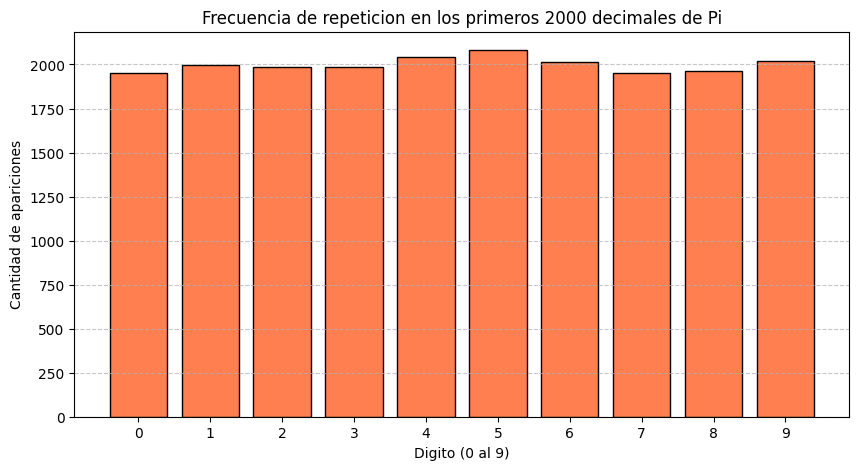

In [27]:
import sympy as sp
import matplotlib.pyplot as plt
from collections import Counter

# 1. Calcular Pi con 2000 decimales exactos
# Usamos sympy porque la libreria basica de matematicas solo entrega 15 decimales
pi_calculado = str(sp.pi.evalf(20000))

# Quitar el "3." inicial para analizar solamente los digitos decimales
solo_decimales = pi_calculado.split('.')[1]

# 2. Contar la frecuencia de cada numero
# Counter agrupa y cuenta cuantas veces se repite cada caracter
conteo = Counter(solo_decimales)

# Ordenar los resultados del 0 al 9
digitos = [str(numero) for numero in range(10)]
frecuencias = [conteo[digito] for digito in digitos]

# 3. Graficar el resultado
plt.figure(figsize=(10, 5))
plt.bar(digitos, frecuencias, color='coral', edgecolor='black')

# Formato del grafico
plt.title('Frecuencia de repeticion en los primeros 2000 decimales de Pi')
plt.xlabel('Digito (0 al 9)')
plt.ylabel('Cantidad de apariciones')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Imprimir el total calculado para verificar
print(f"Total de digitos analizados: {sum(frecuencias)}")

# Mostrar la imagen
plt.show()

## El Teorema del Mono Infinito

Este teorema matemático establece que si un mono presiona teclas al azar en una máquina de escribir durante un tiempo infinito, eventualmente escribirá cualquier texto dado, como las obras completas de Shakespeare.

En este ejercicio, le pediremos a la computadora que actúe como el mono. Generará letras al azar sin detenerse hasta formar la palabra que elijamos.

*Nota importante para evitar bloqueos: Usa una palabra corta (3 o 4 letras como máximo). Agregar una letra extra multiplica la cantidad de intentos necesarios de forma exponencial.*

**Instrucción:** Cambia la palabra objetivo en el código si lo deseas y ejecuta la celda para ver cuántos millones de intentos le toma a la máquina escribirla por pura casualidad.

In [30]:
import random
import string
import time

# 1. Configurar los parametros
palabra_objetivo = "uai"  # Mantenla en 3 letras, imprimir en pantalla hace el proceso mas lento
alfabeto = string.ascii_lowercase
longitud = len(palabra_objetivo)

intentos = 0
texto_generado = ""

print(f"Buscando la palabra '{palabra_objetivo}' usando letras al azar...\n")

# 2. Iniciar el ciclo de escritura aleatoria
while True:
    intentos += 1

    # Elegir una letra al azar y agregarla al texto en memoria
    letra_aleatoria = random.choice(alfabeto)
    texto_generado += letra_aleatoria

    # Mostrar la letra en pantalla en la misma linea
    print(letra_aleatoria, end='', flush=True)

    # Hacer un salto de linea cada 80 letras para ordenar el bloque de texto
    if intentos % 200 == 0:
        print()

    # Descomenta la siguiente linea quitando el '#' si quieres que el "mono" escriba mas lento
    # time.sleep(0.005)

    # Mantener en memoria solo las ultimas letras correspondientes a la longitud de la palabra
    if len(texto_generado) > longitud:
        texto_generado = texto_generado[1:]

    # Verificar si las ultimas letras coinciden con nuestra palabra objetivo
    if texto_generado == palabra_objetivo:
        break

# 3. Mostrar el resultado final
print(f"\n\n¡Exito!")
print(f"La computadora logro escribir '{palabra_objetivo}'.")
print(f"Le tomo {intentos} letras generadas al azar.")

Buscando la palabra 'uai' usando letras al azar...

...

¡Exito!
La computadora logro escribir 'uai'.
Le tomo 36277 letras generadas al azar.
